#### Física de la Radioterapia. Máster de Física Biomédica. Universidad Complutense de Madrid

# Taller sobre calibración e incertidumbres
------

# Ajustes de calibración. Modelos paramétricos lineales

## El caso más *simple*: un único parámetro

En ocasiones, las más favorables, nuestro aparato de medida responde linealmente a la magnitud que queremos medir.

En estos casos para calibrar nuestro aparato basta con determinar un factor de calibración.

Matemáticamente este factor de calibración es la pendiente de la recta que relaciona la magnitud a medir con la respuesta en el aparato.

El proceso de calibración y medida se puede esquematizar de la siguiente forma;

- Calibración (Caracterización de la función de *respuesta*)
    + Fijamos cantidades definidas de la magnitud a medir y cuantificamos la respuesta
    + Determinamos la pendiente de la función de respuesta
- Medida (Utilización de la función de *calibración*)
    + Sometemos a nuestro aparato de medida a cantidades desconocidas de la magnitud a medir y determinamos la respuesta del sistema
    + Mediante la recta de calibración, inversa de la recta de respuesta, convertimos la respuesta en valor medido

> Idealmente si estamos seguros de la linealidad del aparáto y la ausencia de lecturas en ausencia de magnitud a mediir, podemos establecer la calibración a partir de un valor fijo de la magnitud a medir (*patrón*)

#### Calibración de una cámara de ionización
Imaginemos que queremos calibrar una cámara de ionización mediante este procedimiento.

Tendremos unos valores de carga recolectada para diferentes valores fijados de dosis. En ausencia de fugas a dosis cero la cámara tiene lectura cero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Conocido el factor de calibración real

In [2]:
fcr = 0.0341

podemos calcular los valores que leeríamos en ausencia de incertidumbres

In [3]:
D = np.array([0, 1, 2, 4, 10])
L = D * fcr

y representarlo

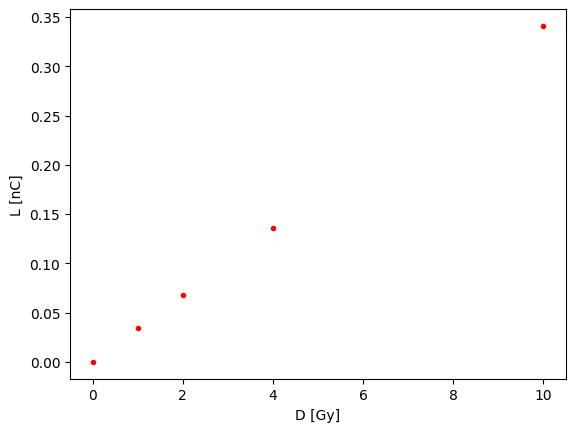

In [4]:
fig, ax = plt.subplots()
ax.plot(D, L, 'r.')
ax.set_xlabel('D [Gy]')
ax.set_ylabel('L [nC]')
plt.show()

Para determinar los factores de calibración importamos el submódulo `stats` del módulo `scipy`

In [5]:
from scipy import stats

y hacemos el ajuste

Parámetros de  la curva de respuesta: Fc: 0.0341, fugas: 0.0000, r: 1.000, error estándar: 0.000



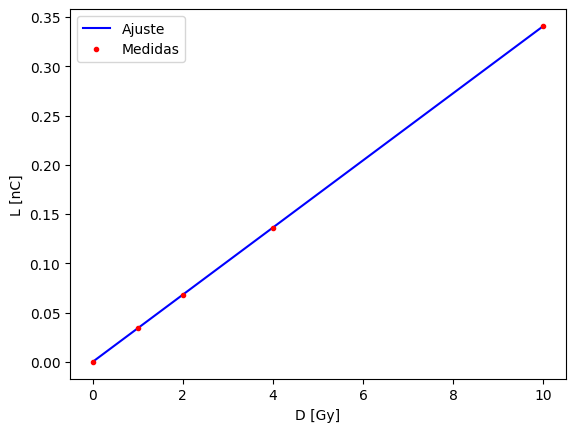

In [6]:
slope, intercept, r_value, p_value, std_err = stats.linregress(D, L)

# Mostar los coeficientes lineales de ajuste y su coeficiente de determinación
print(r'Parámetros de  la curva de respuesta: Fc: %.4f, fugas: %.4f, r: %.3f, error estándar: %.3f'%(slope, intercept, r_value, std_err))
print()

# Representar los datos medidos y sus ajustes
fig, ax = plt.subplots()
ax.plot(D, slope * D + intercept, 'b-', label='Ajuste')
ax.plot(D, L, 'r.', label='Medidas')
ax.set_xlabel('D [Gy]')
ax.set_ylabel('L [nC]')
ax.legend()
plt.show()

Determinamos los valores reales pero este ejemplo es muy poco realista.

En la realidad cada vez que realicemos una medida tendrá asociada una incertidumbre.

Vamos a suponer que la incertidumbre es proporcional al valor medido. Tomemos una incertdumbre del 3% (k = 1) en cada medida.

Empleamos `numpy` para generar valores aleatorios de incertidumbre y perturbamos (hacemos más reales) nuestras medidas.

Intentamos a continuación caracterizar nuestros factores de calibración empleando las medidas con incertidumbres

Parámetros de  la curva de respuesta: Fc: 0.0343, fugas: -0.0012, r: 0.99982, error estándar: 0.00037



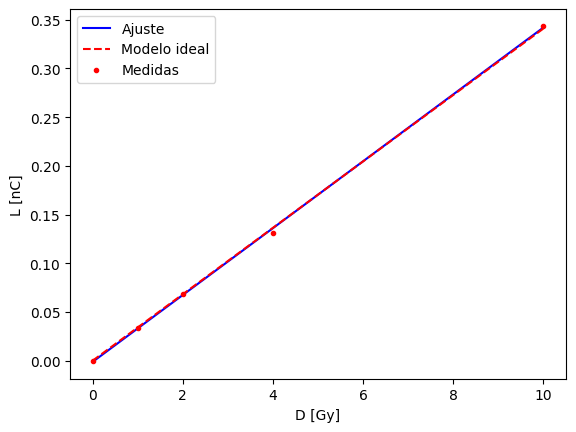

In [7]:
relative_unc = np.random.normal(1, 0.03, 5)
Lr = L * relative_unc

slope, intercept, r_value, p_value, std_err = stats.linregress(D, Lr)

# Mostar los coeficientes lineales de ajuste y su coeficiente de determinación
print(r'Parámetros de  la curva de respuesta: Fc: %.4f, fugas: %.4f, r: %.5f, error estándar: %.5f'%(slope, intercept, r_value, std_err))
print()

# Representar los datos medidos y sus ajustes
fig, ax = plt.subplots()
ax.plot(D, slope * D + intercept, 'b-', label='Ajuste')
ax.plot(D, L, 'r--', label='Modelo ideal')
ax.plot(D, Lr, 'r.', label='Medidas')
ax.set_xlabel('D [Gy]')
ax.set_ylabel('L [nC]')
ax.legend()
plt.show()

Ahora recuperamos una buena aproximación al valor real de calibración pero no exactamente el esperado.

Podemos repetir varias veces el proceso y obtener una estimación de la incertidumbre en la determinación del factor de calibración.

En esta [hoja de cálculo compartida](https://docs.google.com/spreadsheets/d/1KR_ObgwRn4KW9-HoSyYMN84x2x4EWq0s/edit?usp=drive_link&ouid=109366532745677997406&rtpof=true&sd=true) podemos introducir los resultados de los cálculos realizados por los estudiantes en clase.

Leemos el archivo mediante pandas

In [8]:
import pandas as pd

In [9]:
df = pd.read_excel('https://docs.google.com/spreadsheets/d/1KR_ObgwRn4KW9-HoSyYMN84x2x4EWq0s/export?format=xlsx')
display(df)

,Nombre,Apellido(s),Fc
0,Alexis Michele,Acebo,0.0330
1,Pablo,Aguirre Alvarez,0.0331
2,José Miguel,Avilés Oliver,0.0332
3,Hugo,Fernández Bracamonte,0.0331
4,Mikel,González Garmendia,0.0348
5,Jorge,Huecas Mesones,0.0350
6,Pedro,Infante Rodríguez-Rey,0.0340
7,Marcos,L'Hotellerie-Fallois Juarros,0.0344
8,Ángel,Lucena Pérez,0.0341
9,Lucia,Matey Font,0.0334


Y podemos hacer estadísticas. La mejor estimación del $F_c$ será el promedio de todas las determinaciones y la incertidumbre, depende si la referimos a una determinación individual o a la media, será la desviación estándar de la muestra de determinaciones y está dividida por la raíz del número de determinaciones respectivamente.

In [10]:
Fc_estimado, inc_individual, inc_media = df.Fc.mean(), df.Fc.std(), df.Fc.std()/np.sqrt(df.Fc.count())
print('Fc estimado: %.4f +/- %.4f'%(Fc_estimado, inc_media))
print('Incertidumbre de cada determinación +/- %.4f'%(inc_individual))
print('Fc real: %.4f'%fcr)

Fc estimado: 0.0338 +/- 0.0002
Incertidumbre de cada determinación +/- 0.0007
Fc real: 0.0341


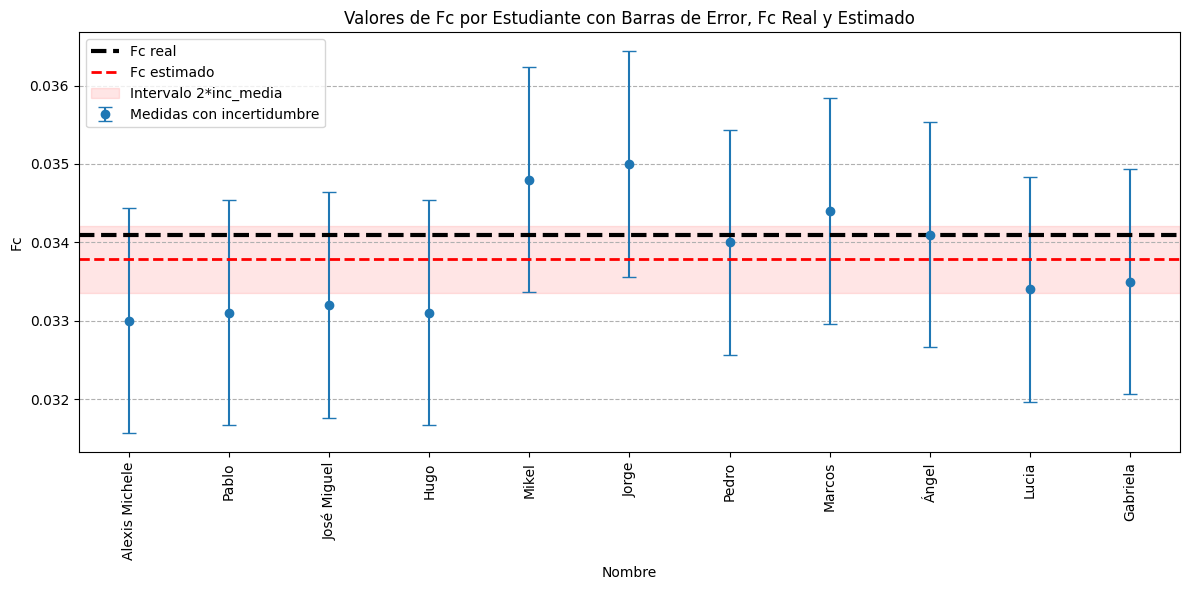

In [11]:
plt.figure(figsize=(12, 6))
plt.errorbar(df.Nombre, df.Fc, yerr=2 * inc_individual, fmt='o', capsize=5, label='Medidas con incertidumbre')
plt.axhline(y=fcr, color='k', linestyle='--', linewidth=3, label='Fc real') # Añadida línea horizontal para Fc real
plt.axhline(y=Fc_estimado, color='r', linestyle='--', linewidth=2, label='Fc estimado') # Añadida línea horizontal para Fc estimado
plt.axhspan(Fc_estimado - 2 * inc_media, Fc_estimado + 2 * inc_media, color='r', alpha=0.1, label='Intervalo 2*inc_media') # Añadida región de incertidumbre
plt.xlabel('Nombre')
plt.ylabel('Fc')
plt.title('Valores de Fc por Estudiante con Barras de Error, Fc Real y Estimado')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

No siempre podemos repetir un experimento varias veces aunque lo anterior muestra que contar con un buen sistema de registro ayuda a caracterizar nuestro sistema.

En caso de contar con un único resultado, la pregunta es ¿existe alguna manera de tener una estimación de la incertidumbre del ajuste, y por tanto de la incertidumbre de la calibración?


In [12]:
from scipy.optimize import curve_fit

def rect_resp(x, a, b):
    return a * x + b

popt, pcov = curve_fit(rect_resp, D, Lr)

Parámetros del ajuste

In [13]:
popt

array([ 0.03432665, -0.00121381])

Matriz de covarianza

In [14]:
pcov

array([[ 1.39944659e-07, -4.75811820e-07],
       [-4.75811820e-07,  3.38665970e-06]])

Una estimación de la incertidumbre del factor de calibración la obtenemos de la raíz del primer elemento de la matriz

In [15]:
np.sqrt(pcov[0,0])

np.float64(0.0003740917792831368)

## Casos más complejos: varios parámetros

En muchas ocasiones la respuesta $L$ de nuestro sistema resulta de la combinación lineal de varios fenómenos descritos por funciones más o menos complejas de la entrada $x$

\begin{equation}
    L(x) = a\, f(x) + b\, g(x) + \dots
\end{equation}

Dentro de estas situaciones están aquellas en las que no conocemos en detalle la física de los fenómenos involucrados y los describimos empíricamente mediante algún tipo de aproximación.

Así ocurre por ejemplo cuando aproximamos la falta de linealidad del sistema mediante una función polinómica de un grado dado.

\begin{equation}
    L(x) = a_0 + a_1\, x + a_2\, x^2 + \dots
\end{equation}

Por ejemplo supongamos que estamos midiendo un proceso de atenuación exponencial

\begin{equation}
    L(x) = a\, e^{-\mu\, x}.
\end{equation}

pero que lo desconocemos. Decidimos aproximar nuestra respuesta por una función polinómica de grado 3.

\begin{equation}
    L(x) = a_0 + a_1\, x + a_2\, x^2 + a_3\, x^3
\end{equation}

que depende por tanto de tres parámetros lineales y un valor de fondo.

Generamos nuestras medidas inlcuida de nuevo una incertidumbre dada en este caso del 2%.


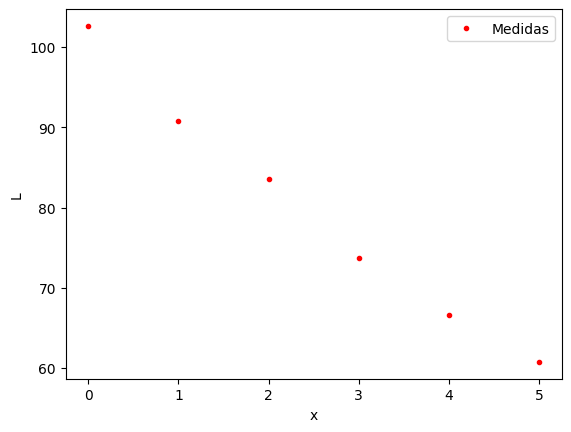

In [16]:
# Parámetros de la fucnión real
a = 100
mu = 0.1
# Incertidumbre relativa
sigma_uncertainty = 0.02
# Incertidumbre de cada medida
rel_uncs = np.random.normal(1, sigma_uncertainty, 6)
# Espesores en los que medimos la atenuación
xs = np.array([0, 1, 2, 3, 4, 5])
# Atenuaciones medidas
Ls = a * np.exp(-mu*xs) * rel_uncs
# Representación gráfica
fig, ax = plt.subplots()
ax.plot(xs, Ls, 'r.', label='Medidas')
ax.set_xlabel('x')
ax.set_ylabel('L')
ax.legend()
plt.show()

Para realizar este tipo de ajuste podemos emplear el módulo `scikit-learn`

In [17]:
from sklearn.linear_model import LinearRegression

Necesitamos calcular la matriz X que tiene en cada columna los valores

\begin{equation}
     [x,  x^2, x^3]
\end{equation}

para todos los espesores x


Coeficientes lineales de ajuste y coeficiente de determinación (score):
a_1: -11.177, a_2: 0.614, a_3: -0.009, fondo: 102.331, score: 0.998



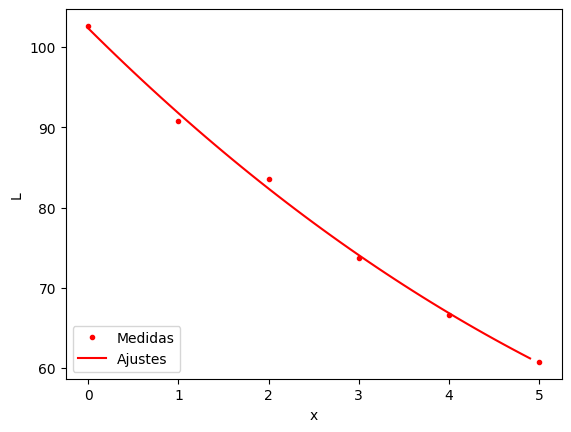

In [19]:
y = Ls
X = np.array([xs.tolist(), (xs**2).tolist(), (xs**3).tolist()]).transpose()

regressor = LinearRegression()

regressor.fit(X, y)
score = regressor.score(X, y)

# Mostar los coeficientes lineales de ajuste y su coeficiente de determinación
print('\nCoeficientes lineales de ajuste y coeficiente de determinación (score):')
print(r'a_1: %.3f, a_2: %.3f, a_3: %.3f, fondo: %.3f, score: %.3f'%(regressor.coef_[0], regressor.coef_[1], regressor.coef_[2], regressor.intercept_, score))
print()

# Representar los datos medidos y sus ajustes
xg = np.arange(xs.min(),xs.max(),0.1)
fig, ax = plt.subplots()
ax.plot(xs, Ls, 'r.', label='Medidas')
Xg = np.array([xg.tolist(), (xg**2).tolist(), (xg**3).tolist()]).transpose()
ax.plot(xg, regressor.predict(Xg), 'r-', label='Ajustes')
ax.set_xlabel('x')
ax.set_ylabel('L')
ax.legend(loc='lower left')
plt.show()

En este caso no tiene senido intentar analizar el significado físico de los coeficientes lineales de ajuste.

Para poder hacerlo necesitamos que las funciones que combinamos linealmente tengan algua justificación física.

Esta forma de modelo multiparamétrico lineal se utiiza a menudo en medicina para el análsis de datos en función de múltiples variables. Por ejemplo supongamos que queremos analizar la incidencia de cáncer en función de la edad, presión arterial, peso, sexo, PSA, condición de fumador, número de cigarrillos fumados al día, cantidad de alcohol ingerido... Estos análisis están limitados por su caracter lineal. En el mejor de los casos los podemos interpretar como una aproximación local a una descripción subyacente más compleja.

Un mejor tratamiento se consigue mediante *redes neuronales*, una sucesión de capas que combinan secuencialmeente las salidas de una con las entradas de la siguiente para ajustar el modelo variando los pesos (parámetros) de las capas.

Este tipo de herramientas se utilizan en *machine learning*. Por eso hemos utilizado las utilidades de regresión del módulo `scikit-learn` para mostrar cómo realizar ajustes multiparamétricos lineales. Estos ajustes se pueden realizar de muchas otras formas pero nos parece interesante introducir estas herramientas.

### Overfitting

Los modelos polinómicos no manejan bien las incertidumbres. A medida que aumentamos el grado del polinomio nos aproximamos más a los valores medidos perdiéndose la capacidad del modelo de implicitamente introudcir información fisica y promediar las medidas, aunque no se hayan realizado en las mismas condiciones.

En nuestro ejemplo tenemos seis valores medidos. Podríamos determinar hasta un polinomio de grado cinco. Para no ser tan extremos, veamos lo que pasa al aumentar un grado el polinomio, pasando de grado 3 a grado 4


Coeficientes lineales de ajuste y coeficiente de determinación (score):
a_1: -14.806, a_2: 4.515, a_3: -1.279, a_4: 0.127, fondo: 102.549, score: 0.999



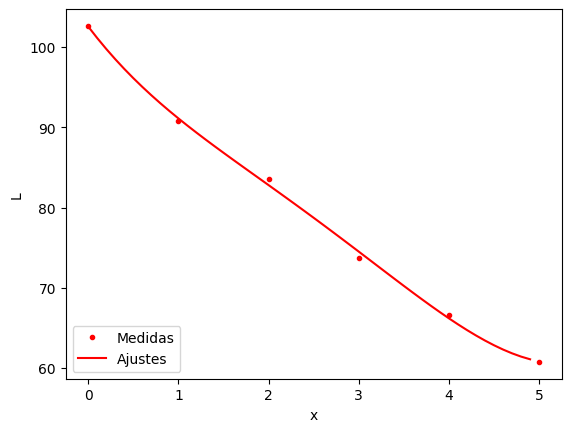

In [20]:
y = Ls
X = np.array([xs.tolist(), (xs**2).tolist(), (xs**3).tolist(), (xs**4).tolist()]).transpose()

regressor = LinearRegression()

regressor.fit(X, y)
score = regressor.score(X, y)

# Mostar los coeficientes lineales de ajuste y su coeficiente de determinación
print('\nCoeficientes lineales de ajuste y coeficiente de determinación (score):')
print(r'a_1: %.3f, a_2: %.3f, a_3: %.3f, a_4: %.3f, fondo: %.3f, score: %.3f'%(regressor.coef_[0], regressor.coef_[1], regressor.coef_[2], regressor.coef_[3], regressor.intercept_, score))
print()

# Representar los datos medidos y sus ajustes
xg = np.arange(xs.min(),xs.max(),0.1)
fig, ax = plt.subplots()
ax.plot(xs, Ls, 'r.', label='Medidas')
Xg = np.array([xg.tolist(), (xg**2).tolist(), (xg**3).tolist(), (xg**4).tolist()]).transpose()
ax.plot(xg, regressor.predict(Xg), 'r-', label='Ajustes')
ax.set_xlabel('x')
ax.set_ylabel('L')
ax.legend(loc='lower left')
plt.show()

Fijémonos en que aunque el coeficiente de determinación ha mejorado, las incertidumbres *tiran* del ajuste y lo que empezamos a tener es un interpolador *suave*, en el mejor de los casos. En situaciones *ruidosas*, en las que las incertidumbres son una aportación importante, este planteamiento aporta muy poco valor. Contar con una aproximación de caracter físico, entender qué es lo que hay detrás de las medidas, es muy importante para que nuestro tratamiento de datos tenga sentido.

La **regularización del modelo** consiste en reducir el número de parámetros para evitar la introducción de parámetros superfluos, parámetros que no son bien determinados en el ajuste. Hablamos de *overfting* cuando un modelo mal regularizado se adapta tanto a las variaciones de nuestro conjunto de medidas que pierde su capacidad de predicción de comportamiento en otras situaciones.

# Ajustes de calibración. Modelos paramétricos no lineales

Supongamos que queremos caracterizar un proceso de atenuación exponencial

\begin{equation}
    L(x) = a\, e^{-\mu\, x}.
\end{equation}

del que hemos obtenido varias medidas $L$ para distintos espesores $x$.

Conocemos la física del proceso descrita por el modelo dado en la ecuación anterior. Nuestro objetivo es a partir de las medidas $\{x, L\}$ obtener los parámetros $[a, \mu]$.

El problema aquí es que para caracterizar el funcionamiento de nuestro sistema tenemos que utilizar un modelo paramétrico con dependencias no lineales.

Para resolver este problema podemos utilizar la función `curve_fit` que ya hemos introducido antes. `curve_fit` necesita una función que describa el modelo

In [21]:
def modf(x, a, mu):
    return a * np.exp(-mu*x)

De acuerdo a la documentación de [curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), como ya hicimos antes, podemos llamar a la función de la forma más minimalista pasando simplemente la función del modelo, las variables independientes y las variables dependientes (las medidas). `curve_fit`nos devolverá los parámetros de ajuste y su matriz de covarianza.

La información que podemos obtener de la matriz de covarianza depende de la interpretación del modelo y de si hemos proporcionado a `curve_fit` estimaciones de las incertidumbres de nuestras medidas

In [22]:
ps, mcov = curve_fit(modf, xs, Ls)

/tmp/ipykernel_219/2908929205.py:2: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-mu*x)


Como muchos otros problemas no lineales es posible que curve_fit diverja. En ocasiones es necesario introducir una estimación razonable de los parámetros iniciales.

In [30]:
ps, mcov = curve_fit(modf, xs, Ls, [98, 0.11])

Los parámetros ajustados

In [24]:
ps

array([102.05889364,   0.10559289])

La matriz de covarianzas

In [31]:
mcov

array([[4.92115440e-01, 1.45405209e-03],
       [1.45405209e-03, 7.49710236e-06]])

Las elementos de la diagonal nos dan las varianzas de los parámetros, que podemos entender como el cuadrado de la incertidumbre en su estimación

In [ ]:
[np.sqrt(mcov)[i, i] for i in range(2)]

[1.7638276346973614, 0.00709058418389589]

O en términos relativos

In [39]:
rel_uncs = [np.sqrt(mcov)[i, i] / ps[i] for i in range(len(ps))]
print(f"Incertidumbre relativa de 'a': {rel_uncs[0]:.4f}")
print(f"Incertidumbre relativa de 'mu': {rel_uncs[1]:.4f}")

Incertidumbre relativa de 'a': 0.0069
Incertidumbre relativa de 'mu': 0.0259


Tenemos incertidumbres relativas del orden de tantos por cien.

Representamos los datos medidos y sus ajustes

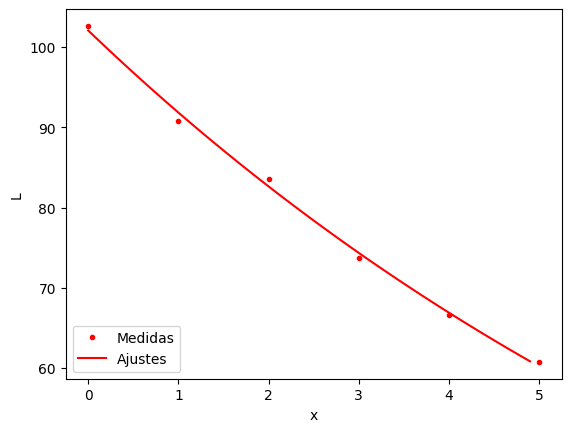

In [25]:
xg = np.arange(xs.min(),xs.max(),0.1)
fig, ax = plt.subplots()
ax.plot(xs, Ls, 'r.', label='Medidas')
ax.plot(xg, modf(xg, *ps), 'r-', label='Ajustes')
ax.set_xlabel('x')
ax.set_ylabel('L')
ax.legend(loc='lower left')
plt.show()

En este caso el modelo físico introduce información implicita, las medidas se tratan simultáneamente aunque no se hayan realizado en las mismas condiciones.

### Incertidumbres en los parámetros
Como hemos hecho el ajuste, sin especificar una incertidumbre para cada medida, `curve_fit` estima las incertidumbres de los parámetros a partir de los residuos del ajuste. Básicamente estima las incertidumbres de las medidas asignando un estimación de desviación estándar calculada con los residuos.

En nuestro caso contamos con una estimación *muy realista* de las incertidumbres de medida

In [26]:
uncs = a * np.exp(-mu*xs) * (1-rel_uncs)

In [47]:
ps_unc, mcov_unc = curve_fit(f=modf, xdata=xs, ydata=Ls, p0=[98, 0.11], sigma=uncs)

In [48]:
ps, ps_unc, (a,mu)

(array([102.05889364,   0.10559289]),
 array([100.21228426,   0.10024028]),
 (100, 0.1))

Introducir las incertidumbres nos mejora el resultado del ajuste porque introduce la información del diferente peso de cada medida.

Si hubiésemos considerado la misma incertidumbre en todos los puntos recuperaríamos el ajuste inicial

In [41]:
eq_uncs = [0.2]*6

ps_eq_unc, mcov_eq_unc = curve_fit(f=modf, xdata=xs, ydata=Ls, p0=[98, 0.11], sigma=eq_uncs)

In [42]:
ps, ps_unc, ps_eq_unc, (a,mu)

(array([102.05889364,   0.10559289]),
 array([100.21228426,   0.10024028]),
 array([102.05889365,   0.10559289]),
 (100, 0.1))

Una consecuencia importante de introducir las incertidumbres en las medidas es que a través del ajuste podemos hacer el transporte de incertidumbres hasta los parámetros de la función del modelo, de manera que después podremos calcular la incertidumbre de calibración.

Si las comparamos en términos relativos

In [46]:
rel_uncs_unc = [np.sqrt(mcov_unc)[i, i] / ps_unc[i] for i in range(len(ps_unc))]
rel_uncs_eq_unc = [np.sqrt(mcov_eq_unc)[i, i] / ps_eq_unc[i] for i in range(len(ps_eq_unc))]

rel_uncs, rel_uncs_unc, rel_uncs_eq_unc

([np.float64(0.006873574424723569), np.float64(0.025930569462794963)],
 [np.float64(0.0036637255563349773), np.float64(0.008995673237913514)],
 [np.float64(0.006873574467935647), np.float64(0.025930569021086893)])